In [ ]:
!git clone https://github.com/dbaranchuk/VisualGenAI.git
%cd VisualGenAI/course_materials_spring_2026/week1_ddpm_dsm/

# DiT architecture. DDPM.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import math
from timm.models.vision_transformer import Attention, Mlp
from tqdm import tqdm
from diffusers.models import AutoencoderKL
from PIL import Image
import matplotlib.pyplot as plt
from utils import show_image_batch, FinalLayer, get_2d_sincos_pos_embed, make_respaced_betas, _extract_into_tensor

In [ ]:
DEVICE = "cuda"

In this seminar, we will look at the architecture of diffusion models and also generate an image using a DiT model pretrained on ImageNet.

ImageNet is a dataset with 1,000 classes.

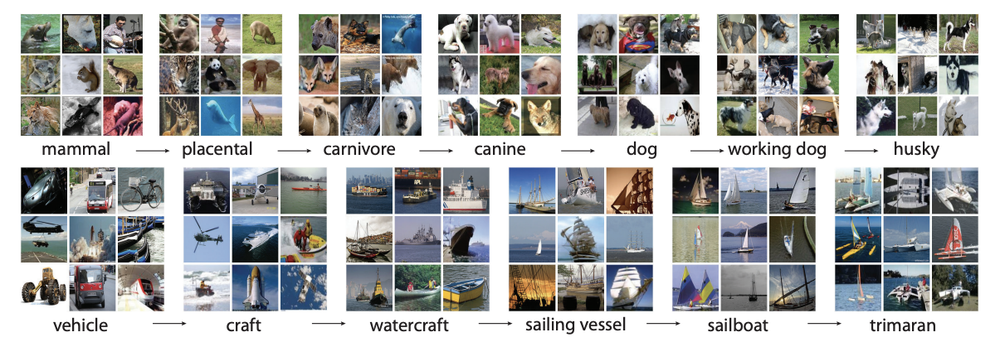

## DiT

The standard architecture for diffusion models today is DiT. Essentially, it is a ViT with additional conditioning on the timestep and class label for conditional generation.

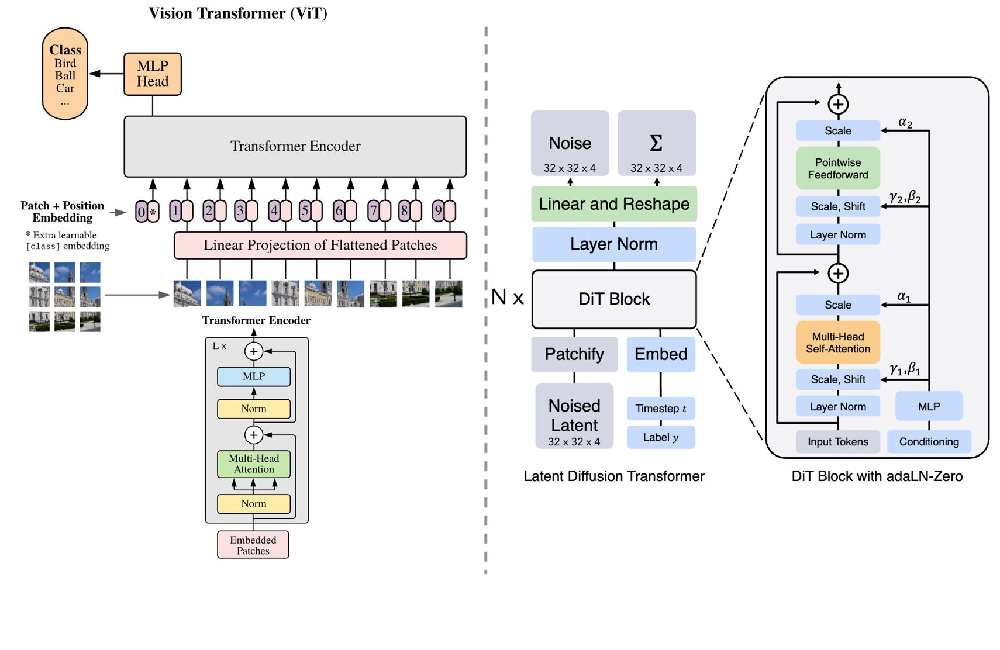

Let's look at how input patchification and tokenization work.

In [ ]:
from typing import Optional
class PatchEmbed(nn.Module):
    def __init__(
        self,
        img_size: Optional[int] = 224,
        patch_size: int = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
        bias: bool = True,
    ):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size, bias=bias)
        self.num_patches = (img_size // patch_size) ** 2

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)  # NCHW -> NLC
        return x

First, we implement the timestep embedding layer. The timestep is encoded using sinusoidal (sin–cos) embeddings and then passed through an MLP.

$$\text{embedding}(t) = \text{MLP}\left(\left[\cos\left(\frac{\text{t}}{10000^{2 \cdot i / d}}\right), \dots, \sin\left(\frac{\text{t}}{10000^{2 \cdot i / d}}\right), \dots\right]\right)\qquad i = 0, 1, \ldots, \frac{d}{2}-1$$

In [ ]:
class TimestepEmbedder(nn.Module):
    """
    Embeds scalar timesteps into vector representations.
    """
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        """
        Create sinusoidal timestep embeddings.
        :param t: a 1-D Tensor of N indices, one per batch element.
                          These may be fractional.
        :param dim: the dimension of the output.
        :param max_period: controls the minimum frequency of the embeddings.
        :return: an (N, D) Tensor of positional embeddings.
        """
        # https://github.com/openai/glide-text2im/blob/main/glide_text2im/nn.py
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32, device=t.device) / half
        )
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

        if dim % 2:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
        t_emb = self.mlp(t_freq)
        return t_emb

For conditional generation, we also need a class embedding. Since the number of classes is finite, we can simply use nn.Embedding. If we want to use classifier-free guidance (CFG) and support unconditional generation, we also need a dedicated “null” embedding that represents the absence of a class label.

In [ ]:
class LabelEmbedder(nn.Module):
    """
    Embeds class labels into vector representations. Also handles label dropout for classifier-free guidance.
    """
    def __init__(self, num_classes, hidden_size, dropout_prob):
        super().__init__()
        use_cfg_embedding = dropout_prob > 0
        self.embedding_table = nn.Embedding(num_classes + use_cfg_embedding, hidden_size)
        self.num_classes = num_classes
        self.dropout_prob = dropout_prob

    def token_drop(self, labels, force_drop_ids=None):
        """
        Drops labels to enable classifier-free guidance.
        """
        if force_drop_ids is None:
            drop_ids = torch.rand(labels.shape[0], device=labels.device) < self.dropout_prob
        else:
            drop_ids = force_drop_ids == 1
        labels = torch.where(drop_ids, self.num_classes, labels)
        return labels

    def forward(self, labels, train, force_drop_ids=None):
        use_dropout = self.dropout_prob > 0
        if (train and use_dropout) or (force_drop_ids is not None):
            labels = self.token_drop(labels, force_drop_ids)
        embeddings = self.embedding_table(labels)
        return embeddings

Like a standard ViT block, a DiT block consists of multi-head self-attention (MHSA) and a feed-forward network (FFN). The key difference from ViT is a timestep and class conditioning implemented via AdaLN ($y=(1 + \gamma)\cdot \text{LN}(x) + \beta$) along with an additional scale $\alpha$ applied before the skip connection. $\gamma, \beta, \alpha$ are predicted given the timestep and class embeddings.

In [ ]:
def modulate(x, shift, scale):
    """
    x: (N, L, D)
    shift, scale: (N, D)
    """
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)


class DiTBlock(nn.Module):
    """
    A DiT block with adaptive layer norm zero (adaLN-Zero) conditioning.
    """
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0, **block_kwargs):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.attn = Attention(hidden_size, num_heads=num_heads, qkv_bias=True, **block_kwargs)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        mlp_hidden_dim = int(hidden_size * mlp_ratio)
        approx_gelu = lambda: nn.GELU(approximate="tanh")
        self.mlp = Mlp(in_features=hidden_size, hidden_features=mlp_hidden_dim, act_layer=approx_gelu, drop=0)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size, bias=True)
        )

    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.adaLN_modulation(c).chunk(6, dim=1)
        x = x + gate_msa.unsqueeze(1) * self.attn(modulate(self.norm1(x), shift_msa, scale_msa))
        x = x + gate_mlp.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x

Let’s plug everything we implemented into the ViT and turn it into a DiT.

In [ ]:
class DiT(nn.Module):
    """
    Diffusion model with a Transformer backbone.
    """
    def __init__(
        self,
        input_size=32,
        patch_size=2,
        in_channels=4,
        hidden_size=1152,
        depth=28,
        num_heads=16,
        mlp_ratio=4.0,
        class_dropout_prob=0.1,
        num_classes=1000,
        learn_sigma=True,
    ):
        super().__init__()
        self.learn_sigma = learn_sigma
        self.in_channels = in_channels
        self.out_channels = in_channels * 2 if learn_sigma else in_channels
        self.patch_size = patch_size
        self.num_heads = num_heads

        self.x_embedder = PatchEmbed(input_size, patch_size, in_channels, hidden_size, bias=True)
        self.t_embedder = TimestepEmbedder(hidden_size)
        self.y_embedder = LabelEmbedder(num_classes, hidden_size, class_dropout_prob)
        num_patches = self.x_embedder.num_patches
        # Will use fixed sin-cos embedding:
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, hidden_size), requires_grad=False)

        self.blocks = nn.ModuleList([
            DiTBlock(hidden_size, num_heads, mlp_ratio=mlp_ratio) for _ in range(depth)
        ])
        self.final_layer = FinalLayer(hidden_size, patch_size, self.out_channels)
        self.initialize_weights()

    def initialize_weights(self):
        # Initialize transformer layers:
        def _basic_init(module):
            if isinstance(module, nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
        self.apply(_basic_init)

        # Initialize (and freeze) pos_embed by sin-cos embedding:
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.x_embedder.num_patches ** 0.5))
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        # Initialize patch_embed like nn.Linear (instead of nn.Conv2d):
        w = self.x_embedder.proj.weight.data
        nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        nn.init.constant_(self.x_embedder.proj.bias, 0)

        # Initialize label embedding table:
        nn.init.normal_(self.y_embedder.embedding_table.weight, std=0.02)

        # Initialize timestep embedding MLP:
        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)

        # Zero-out adaLN modulation layers in DiT blocks:
        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias, 0)

        # Zero-out output layers:
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias, 0)

    def unpatchify(self, x):
        """
        x: (N, T, patch_size**2 * C)
        imgs: (N, H, W, C)
        """
        c = self.out_channels
        p = self.patch_size
        h = w = int(x.shape[1] ** 0.5)
        assert h * w == x.shape[1]

        x = x.reshape(shape=(x.shape[0], h, w, p, p, c))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], c, h * p, h * p))
        return imgs

    def ckpt_wrapper(self, module):
        def ckpt_forward(*inputs):
            outputs = module(*inputs)
            return outputs
        return ckpt_forward

    def forward(self, x, t, y):
        """
        Forward pass of DiT.
        x: (N, C, H, W) tensor of spatial inputs (images or latent representations of images)
        t: (N,) tensor of diffusion timesteps
        y: (N,) tensor of class labels
        """
        x = self.x_embedder(x) + self.pos_embed  # (N, T, D), where T = H * W / patch_size ** 2
        t = self.t_embedder(t)                   # (N, D)
        y = self.y_embedder(y, self.training)    # (N, D)
        c = t + y                                # (N, D)
        for i, block in enumerate(self.blocks):
            x = block(x, c) # (N, T, D)

        x = self.final_layer(x, c)                # (N, T, patch_size ** 2 * out_channels)
        x = self.unpatchify(x)                   # (N, out_channels, H, W)
        return x

As an example, we will use DiT-L/2, where “/2” denotes the patch size.

In [ ]:
def DiT_L_2(**kwargs):
    return DiT(depth=24, hidden_size=1024, patch_size=2, num_heads=16, **kwargs)

In [ ]:
model = DiT_L_2()

Download the model checkpoint and load it into our implementation.

In [ ]:
!wget https://storage.yandexcloud.net/yandex-research/ema_2000000.pt

In [ ]:
ckpt = torch.load("ema_2000000.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [ ]:
model.eval().to(DEVICE)

DiT(
  (x_embedder): PatchEmbed(
    (proj): Conv2d(4, 1024, kernel_size=(2, 2), stride=(2, 2))
  )
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1024, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1024, out_features=1024, bias=True)
    )
  )
  (y_embedder): LabelEmbedder(
    (embedding_table): Embedding(1001, 1024)
  )
  (blocks): ModuleList(
    (0-23): 24 x DiTBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=False)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=False)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, 

We can see that AdaLN contains a large number of parameters (~30%). JFYI, in practice, there are some techniques to reduce the number of parameters, e.g., sharing the same AdaLN weights across multiple DiT blocks and using LoRA per block. 

In [ ]:
num_all_params = sum(p.numel() for p in model.parameters())
f"{num_all_params:,}"

'458,102,816'

In [ ]:
num_adaln_params = sum(p.numel() for i in range(len(model.blocks)) for p in model.blocks[i].adaLN_modulation[-1].parameters()) + \
    sum(p.numel() for p in model.final_layer.adaLN_modulation[-1].parameters())
f"{num_adaln_params:,}"

'153,241,600'

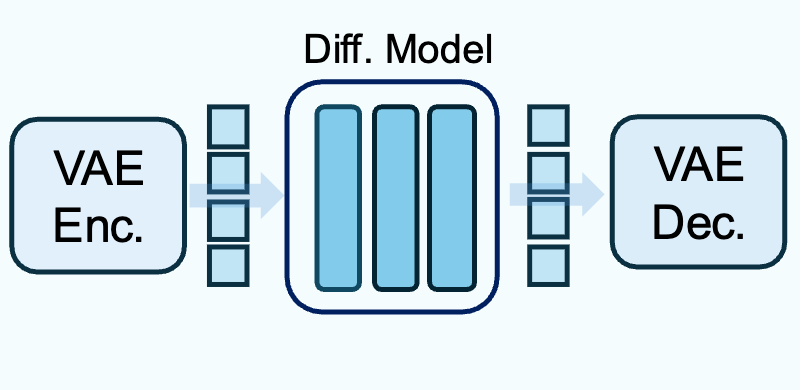

DiT is trained to generate in the VAE latent space rather than in pixel space. This is done for several reasons:

- the latent space has smaller spatial dimensions, making generation cheaper;
- latent space can improve diffusion learnability.

To map an image into latent space, we use a pretrained autoencoder.

In [ ]:
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-ema").to(DEVICE)

Now let’s look at how the noise/denoising schedule is defined. From the lecture, we know that $$x_{t}=\sqrt{1 - \beta_t}x_{t-1} + \sqrt{\beta_t}\varepsilon, \;\;\varepsilon\sim\mathcal{N}(0, I)$$ and equivalently $$x_{t}=\sqrt{\bar\alpha_t}x_0 + \sqrt{1 - \bar\alpha_t}\varepsilon, \;\;\varepsilon\sim\mathcal{N}(0, I)$$, where $$\bar\alpha_t = \prod_{i=1}^t(1-\beta_i)$$

We will use a linear schedule from $\beta_1=10^{-4}$ to $\beta_T = 0.02$

In [ ]:
betas = np.linspace(1e-4, 0.02, 1000)

Now we will implement a class that stores all the diffusion coefficients we need.

In [ ]:
class Diffusion:
    def __init__(
        self,
        betas,
        device
    ):
        """
        Class that simulates Diffusion process. Does not store model or optimizer.
        """
        self.device = device
        betas = torch.from_numpy(betas).double()
        betas = betas.to(device)
        self.betas = betas
        assert len(betas.shape) == 1, "betas must be 1-D"
        assert (betas > 0).all() and (betas <= 1).all()

        self.num_timesteps = int(betas.shape[0])

        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=self.device), self.alphas_cumprod[:-1]], dim=0)  # \bar\alpha_{t-1}

        # calculations for diffusion q(x_t | x_{t-1})
        self.sqrt_alphas_cumprod = self.alphas_cumprod.sqrt()
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # calculations for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod) * betas

In [ ]:
sampling_steps = 100
alphas_cumprod = np.cumprod(1 - betas)
use_ts = np.linspace(0, 999, sampling_steps, dtype=np.int64)
new_betas, t_map = make_respaced_betas(alphas_cumprod, use_ts)
diffusion = Diffusion(new_betas, DEVICE)

Next, we implement the DDPM sampling.

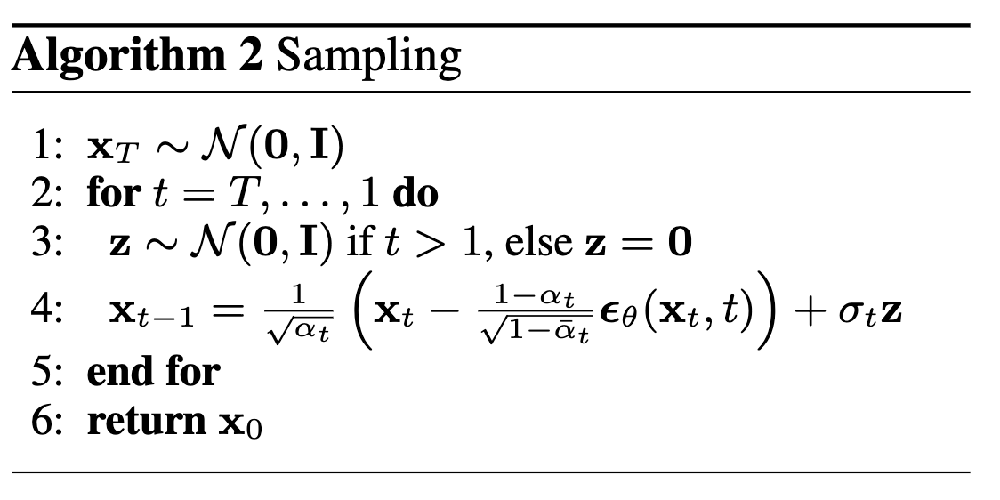

In [ ]:
@torch.no_grad()
def generate(model, diffusion, t_map, y, shape, noise=None, cfg=1.0, y_null=None):
    if noise is None:
        x = torch.randn(*shape, device=DEVICE)
    else:
        x = noise


    B, C, *_ = shape

    for i in tqdm(range(diffusion.num_timesteps - 1, -1, -1)):

        t_diff = torch.tensor([i] * shape[0], device=x.device, dtype=torch.long)
        t_model = torch.tensor([t_map[i]] * shape[0], device=x.device, dtype=torch.long)

        model_output = model(x, t_model, y=y) # first 4 channels mean, last variance

        # CFG
        if cfg > 1.0:
            # eps^* = eps(x, t, y_null) + cfg * (eps(x, t, y) - eps(x, t, y_null))
            uncond_model_output = model(x, t_model, y=y_null)
            model_output = uncond_model_output + cfg * (model_output - uncond_model_output)

        model_output, _ = torch.split(model_output, C, dim=1)

        # mean calculation
        alpha_t = _extract_into_tensor(diffusion.alphas, t_diff, x.shape)
        alpha_t_bar = _extract_into_tensor(diffusion.alphas_cumprod, t_diff, x.shape)

        model_mean = 1 / torch.sqrt(alpha_t) * (x - (1 - alpha_t) / torch.sqrt(1 - alpha_t_bar) * model_output)

        # variance calculation
        model_variance = _extract_into_tensor(diffusion.betas, t_diff, x.shape)

        noise = torch.randn_like(x)
        nonzero_mask = (
            (t_diff != 0).float().view(-1, *([1] * (len(x.shape) - 1)))
        )  # no noise when t == 0

        # x_t-1 calculation
        x = model_mean + nonzero_mask * model_variance ** 0.5 * noise

    # denormalize latent by 0.18215 and decode
    x = vae.decode(x / 0.18215).sample
    x = torch.clamp(127.5 * x + 128.0, 0, 255).permute(0, 2, 3, 1).to("cpu", dtype=torch.uint8).numpy()
    return x

In [ ]:
n = 12 # batch size
z = torch.randn(n, model.in_channels, 32, 32, device=DEVICE) # latent noise
y = torch.randint(0, 1000, (n,), device=DEVICE) # random classes
y_null = torch.tensor([1000] * n, device=DEVICE) # null classes for CFG

100%|██████████| 100/100 [00:29<00:00,  3.34it/s]


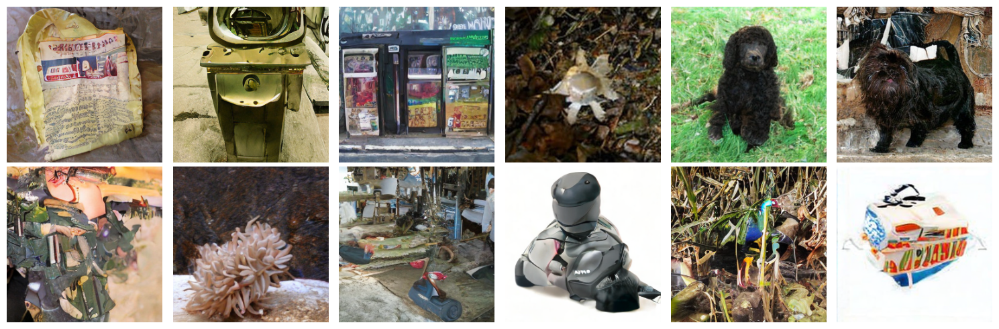

In [ ]:
# DDPM, No CFG
samples = generate(model, diffusion, use_ts, y, z.shape, z)
show_image_batch(samples, n_cols=6);

100%|██████████| 100/100 [00:31<00:00,  3.14it/s]


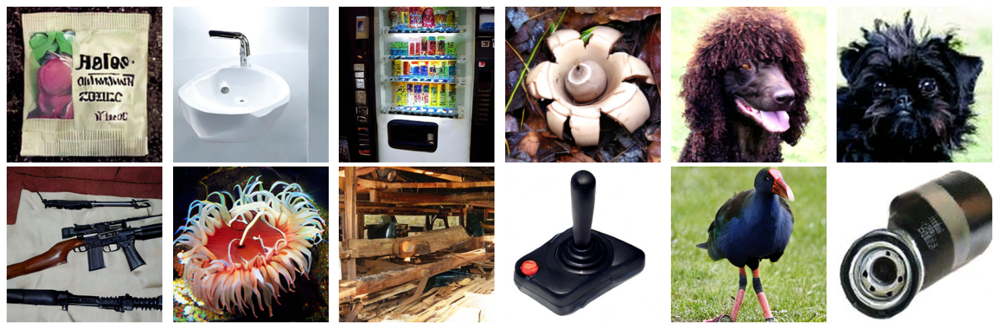

In [ ]:
# DDPM, CFG=4
samples = generate(model, diffusion, use_ts, y, z.shape, z, cfg=4.0, y_null=y_null)
show_image_batch(samples, n_cols=6);

Let's consider another sampling method that we will discuss in detail later: DDIM. It can be used as a deterministic sampler. The idea is as follows: given $x_t$, the model first predicts $x_0$, and then uses this prediction to compute $x_{t-1}$ (which lies on the same trajectory as $x_0$).

$$x_{t-1}
=
\underbrace{
\sqrt{\bar\alpha_{t-1}}
\left(
\frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta^{(t)}(x_t)}{\sqrt{\bar\alpha_t}}
\right)
}_{\text{``predicted $x_0$''}}
+
\underbrace{
\sqrt{1-\bar\alpha_{t-1}}\,\epsilon_\theta^{(t)}(x_t)
}_{\text{``direction pointing to $x_t$''}}
$$

In [ ]:
def predict_x0_from_eps(diffusion, x_t, t, eps):
    return (x_t - _extract_into_tensor(diffusion.sqrt_one_minus_alphas_cumprod, t, x_t.shape) * eps) / _extract_into_tensor(diffusion.sqrt_alphas_cumprod, t, x_t.shape)

In [ ]:
@torch.no_grad()
def generate_ddim(model, diffusion, t_map, y, shape, noise=None, cfg=1.0, y_null=None):
    if noise is None:
        x = torch.randn(*shape, device=DEVICE)
    else:
        x = noise


    B, C, *_ = shape

    for i in tqdm(range(diffusion.num_timesteps - 1, 0, -1)):

        t_diff = torch.tensor([i] * shape[0], device=x.device, dtype=torch.long)
        t_diff_prev = torch.tensor([i - 1] * shape[0], device=x.device, dtype=torch.long)
        t_model = torch.tensor([t_map[i]] * shape[0], device=x.device, dtype=torch.long)

        model_output = model(x, t_model, y=y) # first 4 channels mean, last variance

        if cfg > 1.0:
            uncond_model_output = model(x, t_model, y=y_null)
            model_output = uncond_model_output + cfg * (model_output - uncond_model_output)

        model_output, _ = torch.split(model_output, C, dim=1)

        x0 = predict_x0_from_eps(diffusion, x, t_diff, model_output)

        x = _extract_into_tensor(diffusion.sqrt_alphas_cumprod, t_diff_prev, x.shape) * x0 + \
            _extract_into_tensor(diffusion.sqrt_one_minus_alphas_cumprod, t_diff_prev, x.shape) * model_output

    x = vae.decode(x / 0.18215).sample
    x = torch.clamp(127.5 * x + 128.0, 0, 255).permute(0, 2, 3, 1).to("cpu", dtype=torch.uint8).numpy()
    return x

100%|██████████| 99/99 [00:12<00:00,  8.01it/s]


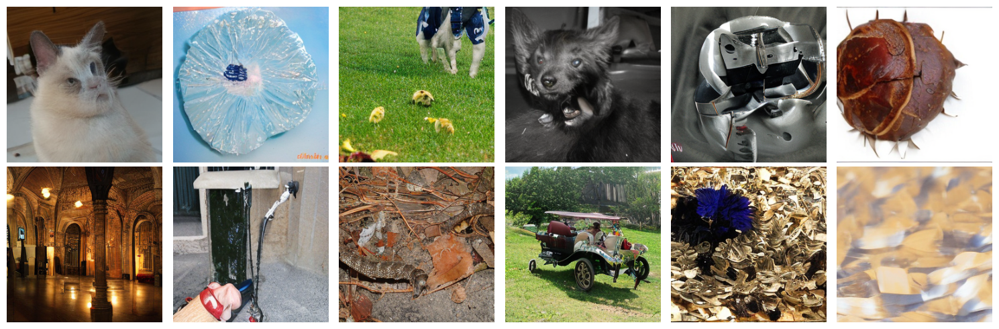

In [ ]:
# DDIM, No CFG
samples = generate_ddim(model, diffusion, use_ts, y, z.shape, z)
show_image_batch(samples, n_cols=6);

100%|██████████| 99/99 [00:24<00:00,  4.00it/s]


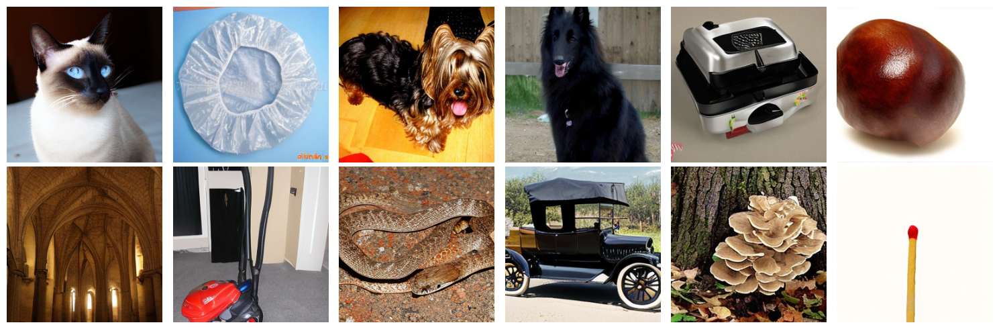

In [ ]:
# DDIM, CFG=4
samples = generate_ddim(model, diffusion, use_ts, y, z.shape, z, cfg=4.0, y_null=y_null)
show_image_batch(samples, n_cols=6);

We can see that with 100 steps, both samplers perform almost identically. Now let’s try reducing the number of steps to 25.

In [ ]:
sampling_steps = 25
use_ts = np.linspace(0, 999, sampling_steps, dtype=np.int64)
new_betas, t_map = make_respaced_betas(alphas_cumprod, use_ts)
diffusion = Diffusion(new_betas, DEVICE)

100%|██████████| 25/25 [00:06<00:00,  4.05it/s]


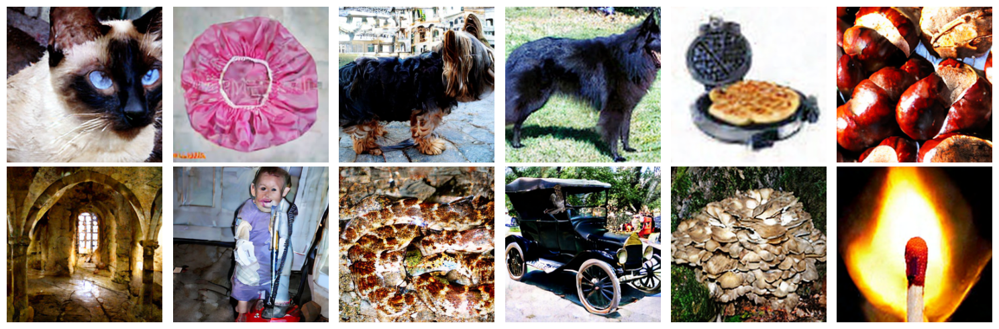

In [ ]:
# DDPM, 25 steps, CFG=4
samples = generate(model, diffusion, use_ts, y, z.shape, z, cfg=4.0, y_null=y_null)
show_image_batch(samples, n_cols=6);

100%|██████████| 24/24 [00:05<00:00,  4.05it/s]


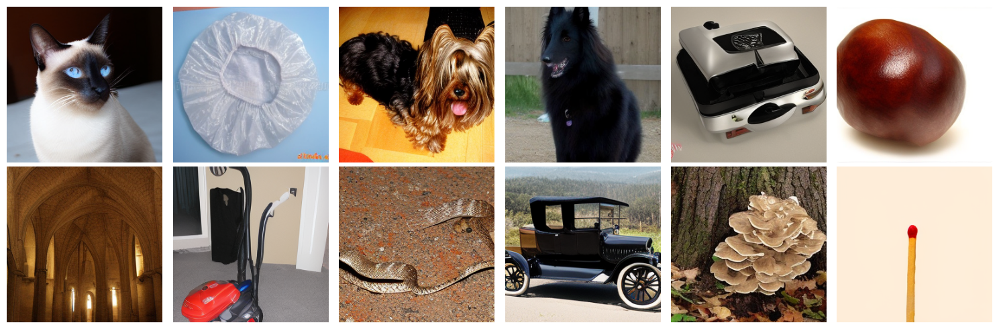

In [ ]:
# DDIM, 25 steps, CFG=4
samples = generate_ddim(model, diffusion, use_ts, y, z.shape, z, cfg=4.0, y_null=y_null)
show_image_batch(samples, n_cols=6);

It can be seen that reducing the number of steps significantly degrades DDPM image quality, while DDIM shows similar performance to 100 steps.